# Setup

In [1]:
import sys
from pathlib import Path

# Replace with actual path to your repo root
project_root = Path.cwd().parent  # or Path("/your/path/to/project/root")
sys.path.append(str(project_root))

In [2]:
import random
import pandas as pd
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import joblib

from transform_emr.embedder import EMREmbedding
from transform_emr.transformer import GPT
from transform_emr.dataset import DataProcessor, EMRTokenizer, EMRDataset
from transform_emr.inference import infer_event_stream
from transform_emr.config.model_config import *
from transform_emr.config.dataset_config import *

# Evaluation Functions

In [13]:
def evaluate_events(true_df, gen_df, outcomes=OUTCOMES, time_bias=48, verbose=False):
    """
    Evaluate predicted events against true events.

    Parameters:
    - true_df: Ground truth events (must include RawConcept, TimePoint)
    - gen_df: Predicted events (must include Token, TimePoint, IsInput) + input events up to time k
    - outcomes: List of outcome labels to evaluate
    - time_bias: Allowed time window (in hours) for time-aware evaluation

    Returns:
    - results: Dict with overall and per-class metrics, both time-aware and standard
    """
    def compute_metrics(tp, fp, fn):
        precision = tp / (tp + fp) if tp + fp else 0.
        recall = tp / (tp + fn) if tp + fn else 0.
        f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.
        acc = tp / (tp + fp + fn) if tp + fp + fn else 0.
        return float(precision), float(recall), float(f1), float(acc)

    # ✅ Step 1: For each PatientID, get prediction start time
    cutoff_map = gen_df[gen_df["IsInput"] == 1].groupby("PatientID")["TimePoint"].max()
    
    # ✅ Step 2: Keep only generated outcomes from pred_df
    pred_df = gen_df[(gen_df["IsInput"] == 0) & (gen_df["Token"].isin(outcomes))]
    pred_df = pred_df.rename(columns={"Token": "ConceptName", "TimePoint": "PredTime"})

    # ✅ Step 3: Filter true_df to only include outcome events after the cutoff
    true_df = true_df[true_df["RawConcept"].isin(outcomes)]
    true_df = true_df.rename(columns={"RawConcept": "ConceptName", "TimePoint": "TrueTime"})

    # Map prediction start to each row in true_df
    true_df = true_df.merge(cutoff_map.rename("CutoffTime"), on="PatientID", how="inner")
    true_df = true_df[true_df["TrueTime"] > true_df["CutoffTime"]]
    true_df = true_df.drop(columns=["CutoffTime"])

    # ✅ Step 4: Merge and match
    merged = true_df.merge(pred_df, on=["PatientID", "ConceptName"], how="outer", indicator=True)
    merged["TP"] = merged["_merge"] == "both"
    merged["FP"] = merged["_merge"] == "right_only"
    merged["FN"] = merged["_merge"] == "left_only"

    # ✅ Step 5: Time-aware TP (within time_bias)
    merged["TimeErr"] = merged["PredTime"] - merged["TrueTime"]
    merged["TP_timeaware"] = merged["TP"] & (merged["TimeErr"].abs() <= time_bias)

    # ✅ Step 6: Aggregate metrics
    results = {"OVERALL": {}, "PER_CLASS": {}}
    for concept in outcomes:
        sub = merged[merged["ConceptName"] == concept]
        tp, fp, fn = sub["TP"].sum(), sub["FP"].sum(), sub["FN"].sum()
        tpt = sub["TP_timeaware"].sum()
        p, r, f1, acc = compute_metrics(tp, fp, fn)
        _, _, f1_t, acc_t = compute_metrics(tpt, fp, fn)

        results["PER_CLASS"][concept] = {
            "precision": p,
            "recall": r,
            "f1": f1,
            "accuracy": acc,
            "f1_timeaware": f1_t,
            "accuracy_timeaware": acc_t,
            "support": int(tp + fn),
            "total_pred": int(tp + fp),
        }

    tp, fp, fn = merged["TP"].sum(), merged["FP"].sum(), merged["FN"].sum()
    tpt = merged["TP_timeaware"].sum()
    p, r, f1, acc = compute_metrics(tp, fp, fn)
    _, _, f1_t, acc_t = compute_metrics(tpt, fp, fn)

    results["OVERALL"] = {
        "f1": float(compute_metrics(tp, fp, fn)[2]),
        "precision": float(compute_metrics(tp, fp, fn)[0]),
        "recall": float(compute_metrics(tp, fp, fn)[1]),
        "accuracy": float(compute_metrics(tp, fp, fn)[3]),
        "f1_timeaware": float(compute_metrics(tpt, fp, fn)[2]),
        "accuracy_timeaware": float(compute_metrics(tpt, fp, fn)[3]),
    }

    if verbose:
        print("\n📊 Evaluation Summary:")
        for k, v in results["OVERALL"].items():
            print(f"  {k:20}: {v:.4f}")
        print("\n🔍 Per-Outcome Evaluation:")
        for concept, scores in results["PER_CLASS"].items():
            f1 = scores['f1']
            acc = scores['accuracy']
            support = scores['support']
            total_preds = scores['total_pred']
            print(f"  {concept:30}: F1 = {f1:.4f}, Acc = {acc:.4f}, Support = {support}, Total Preds = {total_preds}")
        return

    return results

In [14]:
# Sample on random data with k=5
EXCEL_FILE = r"C:\Users\yonat\CodeProjects\event-prediction-in-diabetes-care\checkpoints\inference_results.xlsx"
input_df = pd.read_excel(EXCEL_FILE, sheet_name="Input Events")
gen_df   = pd.read_excel(EXCEL_FILE, sheet_name="Generated Events")

evaluate_events(input_df, gen_df, verbose=True)


📊 Evaluation Summary:
  f1                  : 0.2105
  precision           : 0.1500
  recall              : 0.3529
  accuracy            : 0.1176
  f1_timeaware        : 0.0426
  accuracy_timeaware  : 0.0217

🔍 Per-Outcome Evaluation:
  RELEASE                       : F1 = 0.6000, Acc = 0.4286, Support = 6, Total Preds = 4
  DEATH                         : F1 = 0.0000, Acc = 0.0000, Support = 0, Total Preds = 3
  KETOACIDOSIS                  : F1 = 0.0000, Acc = 0.0000, Support = 0, Total Preds = 0
  KIDNEY_DISORDER               : F1 = 0.4444, Acc = 0.2857, Support = 2, Total Preds = 7
  COMA                          : F1 = 0.0000, Acc = 0.0000, Support = 0, Total Preds = 3
  EYE_DISORDER                  : F1 = 0.4000, Acc = 0.2500, Support = 2, Total Preds = 3
  NERVOUS_SYSTEM_DISORDER       : F1 = 0.0000, Acc = 0.0000, Support = 1, Total Preds = 0
  VASCULAR_DISORDER             : F1 = 0.0000, Acc = 0.0000, Support = 1, Total Preds = 2
  OTHER_COMPLICATION            : F1 = 0.000

# Create Events Trajectories on Test and Evaluate

In [5]:
def evaluate_across_k(model, df_all, ctx_df_all, tokenizer, scaler,
                      k_range=range(3, 14), max_len=500, temperature=1.0, time_bias=48):
    """
    Runs inference and evaluation across a range of K-day cutoffs before discharge.

    Parameters:
    - model (nn.Module): Trained transformer model (with embedder loaded in).
    - df_all (DataFrame): Full input event data.
    - ctx_df_all (DataFrame): Contextual metadata per visit/person.
    - tokenizer (Tokenizer): Tokenizer used by EMRDataset.
    - scaler: Scaler for numerical features.
    - k_range (range): Cutoff values (in days before discharge), default range(3, 14).
    - max_len (int): Max sequence length for generation.
    - temperature (float): Sampling temperature for inference.
    - time_bias (int): Time delta (in hours) allowed for time-aware evaluation.

    Returns:
    - results (dict): Maps each K to its evaluation metrics from `evaluate_events()`.
    """
    results = {}

    # 🔁 Prepare full gold data once (with full event stream)
    full_processor = DataProcessor(df_all.copy(), ctx_df_all.copy(), scaler=scaler)
    df_gt, ctx_gt = full_processor.run()
    all_tokens_df = EMRDataset(df_gt, ctx_gt, tokenizer=tokenizer).tokens_df

    for i, k in enumerate(tqdm(k_range, desc="Evaluating by K", position=0)):
        # 🔁 Slice data up to K days before release
        processor = DataProcessor(df_all.copy(), ctx_df_all.copy(), scaler=scaler, max_input_days=k)
        df_k, ctx_k = processor.run()
        dataset_k = EMRDataset(df_k, ctx_k, tokenizer=tokenizer)

        # 🔮 Predict from K forward
        desc = f"Generating for k={k}"
        gen_df = infer_event_stream(model, dataset_k, max_len=max_len, temperature=temperature, tqdm_position=1, tqdm_desc=desc)

        # 👥 Filter ground truth to only patients in the generated set
        pids = gen_df["PatientID"].unique()
        gold_df = all_tokens_df[all_tokens_df["PatientID"].isin(pids)]

        # 🧮 Evaluate
        results[k] = evaluate_events(gold_df, gen_df, time_bias=time_bias, verbose=False)

    return results

In [7]:
# Load test data
print("Loading dataset...")
df = pd.read_csv(TEST_TEMPORAL_DATA_FILE, low_memory=False)
ctx_df = pd.read_csv(TEST_CTX_DATA_FILE)

# ⚠️ Subset: Pick N random patients for this inference batch
print("Getting subset...")
patient_ids = df["PatientID"].unique()
N = 5  # adjust as needed
selected_ids = sorted(random.sample(list(patient_ids), N))

df_subset = df[df["PatientID"].isin(selected_ids)].copy()
ctx_subset = ctx_df.loc[selected_ids].copy()

# Load tokenizer and scaler
print("Loading resources...")
tokenizer = EMRTokenizer.load(Path(CHECKPOINT_PATH) / "tokenizer.pt")
scaler = joblib.load(Path(CHECKPOINT_PATH) / "scaler.pkl")

# Load models
print("Loading model and generating predictions...")
embedder, _, _, _, _ = EMREmbedding.load(EMBEDDER_CHECKPOINT, tokenizer=tokenizer)
model, _, _, _, _ = GPT.load(TRANSFORMER_CHECKPOINT, embedder=embedder)
model.eval()

results = evaluate_across_k(model, df_subset, ctx_subset, tokenizer, scaler, k_range=range(3, 8), max_len=500, temperature=1.0, time_bias=48)

Loading dataset...
Getting subset...
Loading resources...
Loading model and generating predictions...
[GPT]: Total params: 2.52 M
[GPT]: Compiling model with torch.compile()


Evaluating by K: 100%|██████████| 5/5 [01:42<00:00, 20.49s/it]


# Output 1: Performance Trend over K

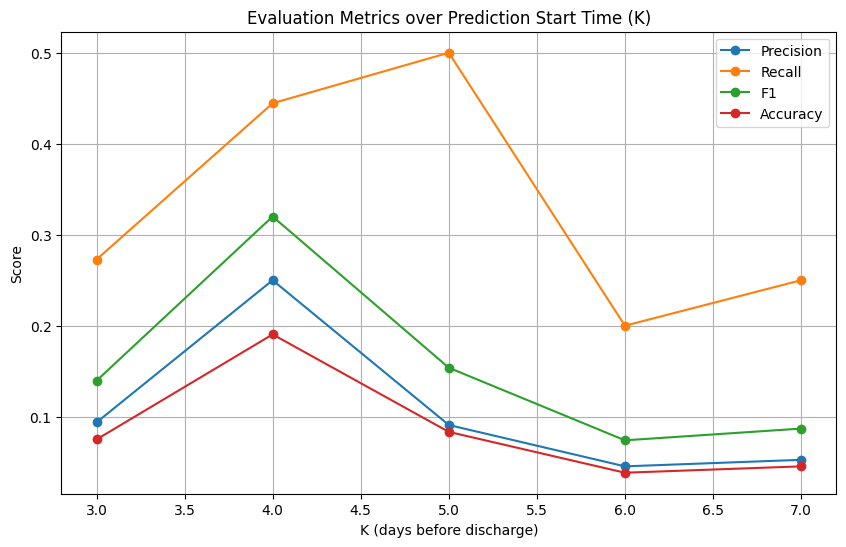

In [9]:
def plot_metrics_trend(results):
    ks = sorted(results.keys())
    precision = [results[k]["OVERALL"]["precision"] for k in ks]
    recall = [results[k]["OVERALL"]["recall"] for k in ks]
    f1 = [results[k]["OVERALL"]["f1"] for k in ks]
    acc = [results[k]["OVERALL"]["accuracy"] for k in ks]

    plt.figure(figsize=(10, 6))
    plt.plot(ks, precision, label="Precision", marker='o')
    plt.plot(ks, recall, label="Recall", marker='o')
    plt.plot(ks, f1, label="F1", marker='o')
    plt.plot(ks, acc, label="Accuracy", marker='o')
    plt.xlabel("K (days before discharge)")
    plt.ylabel("Score")
    plt.title("Evaluation Metrics over Prediction Start Time (K)")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_metrics_trend(results)

# Output 2: Accuracy per Outcome Type (3 Rows)

In [10]:
def build_3x_matrix(results):
    rows = ["RELEASE", "DEATH", "COMPLICATION"]
    matrix = {r: [] for r in rows}
    for k in sorted(results):
        per_class = results[k]["PER_CLASS"]
        for r in rows:
            acc = per_class.get(r, {}).get("accuracy", 0.0)
            matrix[r].append(acc)
    return pd.DataFrame(matrix, index=sorted(results.keys())).T

build_3x_matrix(results)

,3,4,5,6,7
RELEASE,0.6,0.5,0.333333,0.5,1.0
DEATH,0.0,0.0,0.000000,0.0,0.0
COMPLICATION,0.0,0.0,0.000000,0.0,0.0


# Output 3: Accuracy per Unique Outcome Label

In [11]:
def build_full_outcome_matrix(results):
    concepts = sorted({c for r in results.values() for c in r["PER_CLASS"]})
    matrix = {c: [] for c in concepts}
    for k in sorted(results):
        for c in concepts:
            acc = results[k]["PER_CLASS"].get(c, {}).get("accuracy", 0.0)
            matrix[c].append(acc)
    return pd.DataFrame(matrix, index=sorted(results.keys())).T

build_full_outcome_matrix(results)

,3,4,5,6,7
CARDIOVASCULAR_DISORDER,0.0,1.0,1.000000,0.0,0.0
COMA,0.0,0.0,0.000000,0.0,0.0
DEATH,0.0,0.0,0.000000,0.0,0.0
DEMENTIA,0.0,0.0,0.000000,0.0,0.0
EYE_DISORDER,0.0,0.0,0.000000,0.0,0.0
INFECTION,0.0,1.0,0.000000,0.0,0.0
KETOACIDOSIS,0.0,0.0,0.000000,0.0,0.0
KIDNEY_DISORDER,0.0,0.0,0.000000,0.0,0.0
MUSCULOSKELETAL_COMPLICATION,0.0,0.0,0.000000,0.0,0.0
NERVOUS_SYSTEM_DISORDER,0.0,0.0,0.000000,0.0,0.0


# Outcome 4: Time-Aware Accuracy Table

In [12]:
def build_timeaware_matrix(results):
    concepts = sorted({c for r in results.values() for c in r["PER_CLASS"]})
    matrix = {c: [] for c in concepts}
    for k in sorted(results):
        for c in concepts:
            acc_t = results[k]["PER_CLASS"].get(c, {}).get("accuracy_timeaware", 0.0)
            matrix[c].append(acc_t)
    return pd.DataFrame(matrix, index=sorted(results.keys())).T

build_timeaware_matrix(results)

,3,4,5,6,7
CARDIOVASCULAR_DISORDER,0.000000,0.000000,1.0,0.0,0.0
COMA,0.000000,0.000000,0.0,0.0,0.0
DEATH,0.000000,0.000000,0.0,0.0,0.0
DEMENTIA,0.000000,0.000000,0.0,0.0,0.0
EYE_DISORDER,0.000000,0.000000,0.0,0.0,0.0
INFECTION,0.000000,0.000000,0.0,0.0,0.0
KETOACIDOSIS,0.000000,0.000000,0.0,0.0,0.0
KIDNEY_DISORDER,0.000000,0.000000,0.0,0.0,0.0
MUSCULOSKELETAL_COMPLICATION,0.000000,0.000000,0.0,0.0,0.0
NERVOUS_SYSTEM_DISORDER,0.000000,0.000000,0.0,0.0,0.0
